In [1]:
# Setup: make `src` importable, load the data once, precompute word lengths.
import os
import sys

# Walk up from the current working directory to find the repo root (the dir
# containing `src/`), so this works whether Jupyter starts in notebooks/ or root.
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "src")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_pubmed_rct, LABELS

RESULTS_DIR = os.path.join(_root, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120, "font.size": 11})

# Load once; reuse `train` for every plot below.
splits = load_pubmed_rct()
train = splits["train"].copy()
train["n_words"] = train["text"].str.split().map(len)

print(f"Train examples: {len(train):,}")
train.head()

Repo card metadata block was not found. Setting CardData to empty.


Loaded dataset from: armanc/pubmed-rct20k


Train examples: 176,642


,text,label,n_words
0,To investigate the efficacy of @ weeks of dail...,OBJECTIVE,49
1,A total of @ patients with primary knee OA wer...,METHODS,27
2,Outcome measures included pain reduction and i...,METHODS,15
3,Pain was assessed using the visual analog pain...,METHODS,14
4,Secondary outcome measures included the Wester...,METHODS,35


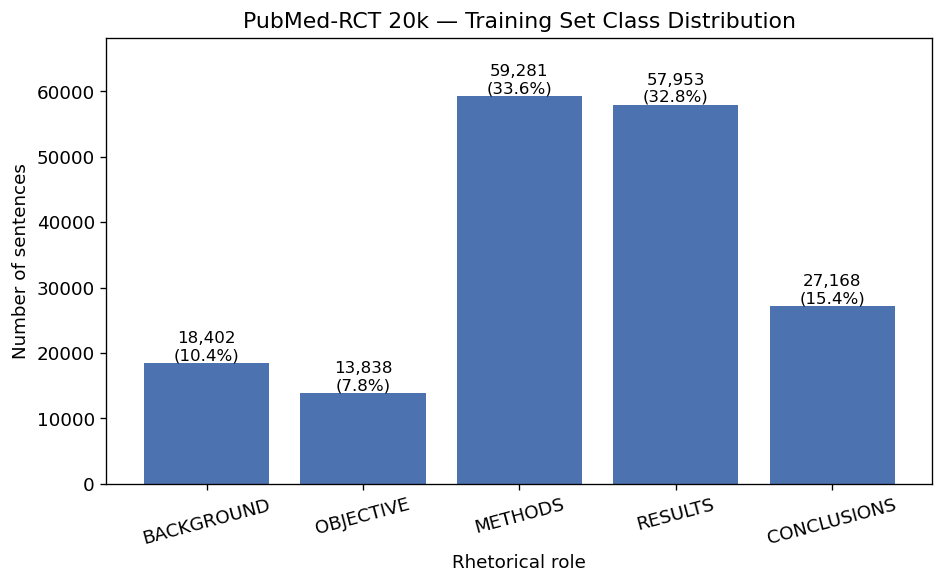

In [2]:
# Plot 1: class distribution on the training set (counts + percentages).
counts = train["label"].value_counts().reindex(LABELS).fillna(0).astype(int)
total = int(counts.sum())
pcts = 100.0 * counts / total

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(LABELS, counts.values, color="#4C72B0")

for bar, c, p in zip(bars, counts.values, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{c:,}\n({p:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("PubMed-RCT 20k \u2014 Training Set Class Distribution")
ax.set_xlabel("Rhetorical role")
ax.set_ylabel("Number of sentences")
ax.set_ylim(0, counts.max() * 1.15)
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "class_distribution.png"))
plt.show()

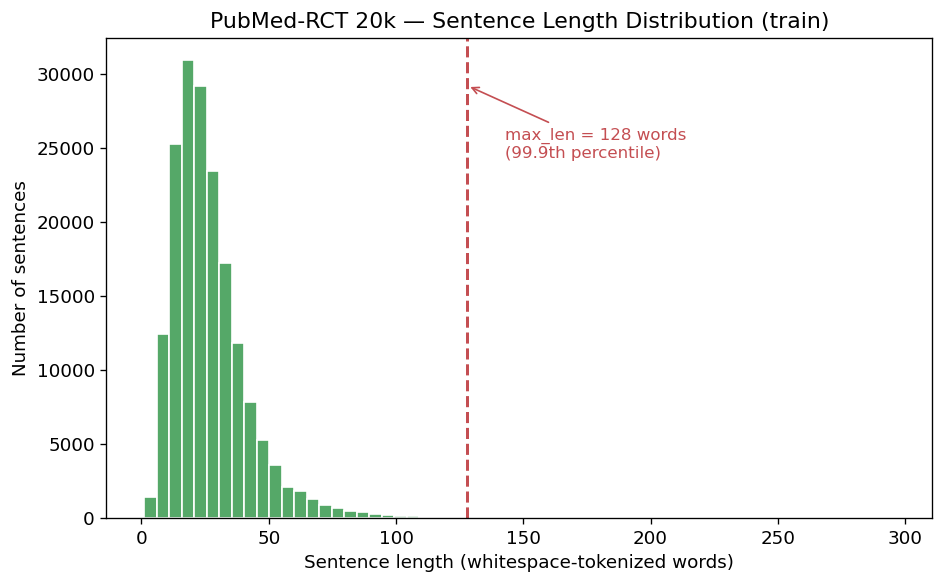

In [3]:
# Plot 2: sentence length (in words) histogram, with the 128-token cap marked.
MAX_LEN = 128
pct_at_cap = 100.0 * (train["n_words"] <= MAX_LEN).mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train["n_words"], bins=60, color="#55A868", edgecolor="white")
ax.axvline(MAX_LEN, color="#C44E52", linestyle="--", linewidth=1.8)
ax.annotate(
    f"max_len = {MAX_LEN} words\n({pct_at_cap:.1f}th percentile)",
    xy=(MAX_LEN, ax.get_ylim()[1] * 0.9),
    xytext=(MAX_LEN + 15, ax.get_ylim()[1] * 0.75),
    arrowprops=dict(arrowstyle="->", color="#C44E52"),
    color="#C44E52",
    fontsize=10,
)

ax.set_title("PubMed-RCT 20k \u2014 Sentence Length Distribution (train)")
ax.set_xlabel("Sentence length (whitespace-tokenized words)")
ax.set_ylabel("Number of sentences")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "sentence_length_hist.png"))
plt.show()

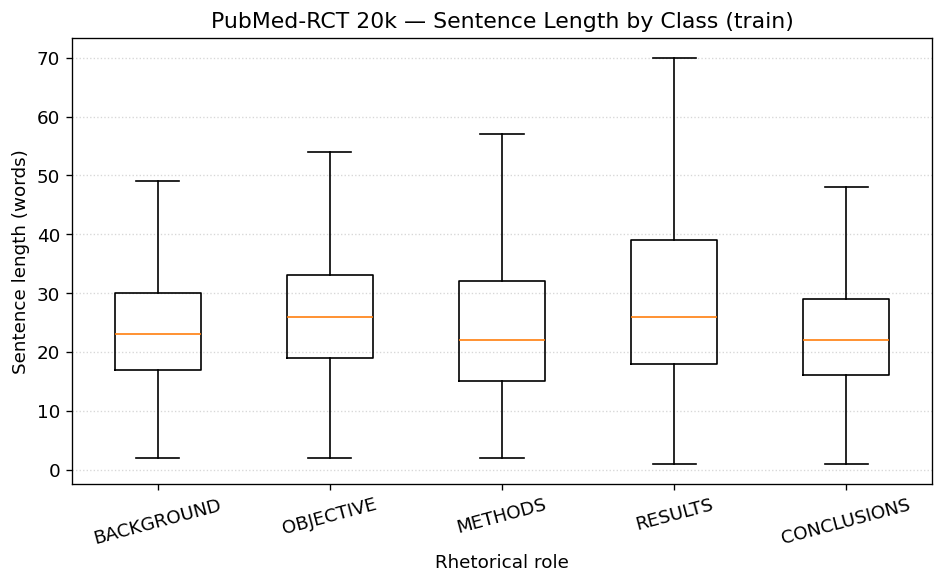

In [4]:
# Plot 3: sentence length (in words) per class, boxplot in canonical order.
data_by_class = [train.loc[train["label"] == label, "n_words"].values for label in LABELS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_by_class, tick_labels=LABELS, showfliers=False)

ax.set_title("PubMed-RCT 20k — Sentence Length by Class (train)")
ax.set_xlabel("Rhetorical role")
ax.set_ylabel("Sentence length (words)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "sentence_length_by_class.png"))
plt.show()